# Report

## Overview
This assignment involved improving success rate for predicting which customers would purchase a term deposit.
    
For each customer, demographic information about the customer was given, including age, occupation, marital status, education level, housing, and financial information.

In addition to demographic information, behavioral information about the customers was recorded, including when the customer was contacted, how the customer was contacted, how many times, and the duration of the most recent call.

## Initial Study
For the first phase of the study, only the demographic information was used to predict whether a customer would purchase the product. The algorithm used was the Decision Tree Classifier. Because the cost of losing a potential subscriber versus the cost of calling a customer who eventually did not subscribe was not known, the metric optimized for was the F1-score for subscribers, in order to balance recall with precision.

### Class Weights
The data file given had 40,000 entries, around 3,000 of which were subscribers, or about 93% non-subscribers. When optimizing, class weights were used to try and maximize the score. Optuna was used to vary the hyperparameters in the Decision Tree algorithm, but Optuna was not allowed to vary the class weights. Instead, those were kept fixed, and manually changed in order to find which weight have the best result. This way, Optuna would be able to search parameter space for each weight value.

The weight value that yielded the best score was was weighing a subscriber 31 times more than a non-subscriber. In particular, for a test sample of 8,000 customers, the algorithm correctly predicted 459 out of 579 subscribers.


## Next Phase and Attempted Improvements
After achieving an F1 score of 0.42 for subscribers using only demographic and financial infomration, a couple of other attempt were made to improve the outcome.
First, there were missing education values, and an attempt was made to fill them in using other demographic information.
Second, behavioral information was used to try and further refine the prediction.

## Educational Information
Around 3% of the customers had education unrecorded. This corresponded to the first 3% contacted (rememeber the date of contact was recorded), indicating that the education of the potential client was not asked by the interviewer until after the data had started to be taken.

The Decision Tree Algorithm was used to predict the education level based on other demographic and financial information. Then, this information was fed into the original dataset, and the prediction process repeated. Unfortunately, the added education information did not improve the predictive power of the original algorithm. In fact, it slightly reduced it.

## Behavioral Information
The next phase of the project was to add the behavioral information to those predicted to subscribe from the demographic information, and use this to try to further refine predictions. For this task, the Nearest Centroid algorithm was used. Infomration included date of contact, duration of call, and number of times contacted. This further information did not significanly improve predictive power, so it was scrapped.

# K-Means and Principal Component Analysis
The last phase of the project was getting a better idea of the clients who chose to purchase the product through the PCA  and K-means algorithms. First, the K-means algorithm was used to cluster the clients into five cohorts based on age, job, marriage status, housing status, loan status, and balance.

What can be seen from the clustering is that two particular cohorts are centralized around age: the old (over 60, all retired) and the young (under 30, all students). The elder cohort had the highest balance. Among the remaining cohorts, one was entirely composed of individuals in management, who were primarily middle aged (mid 40's).

The other two consisted of entirely mixed jobs, and ages ranging from 30's to 40's. One of them had a balance that was lower than the others. Below is a chart that shows the cohorts.


|  Cohort     |  Age        |  Balance    |Job          | Color       |
|-------------|-------------|-------------|-------------|-------------|
|0 (old)      |63           |2318         | retired     | purple      |
|1 (young)    |27           |1658         | student     | dark blue   |
|2 (low bal.) |42           |1400         | mixed       | dark green  |
|3 (mixed)    |33           |1645         | mixed       | light green |
|4 (managers) |43           |1757         | management  | yellow      |


The last step was to cluster the data points using the Principal Component Analysis algorithm, projecting it onto a 2-D plot. Then, the points were then colored according to which cohort K-Means put them into.

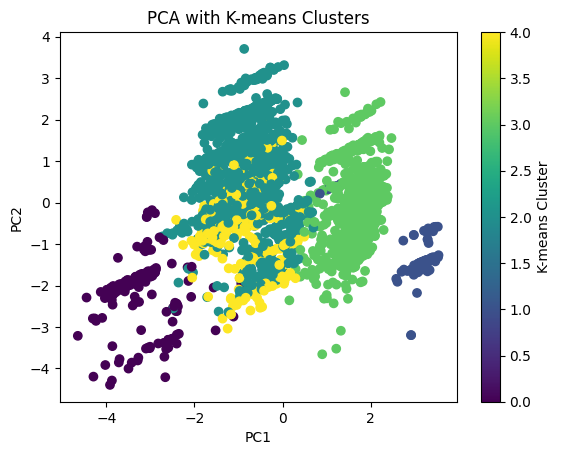



As can be seen from the scatter plot, the old and young cohorts are on opposite ends of the horizontal axis, while the low balance and management cohorts are in the center. The mixed cohort, which has the second youngest mean age, is closer to the young cohort, indicating that the horizontal axis is strongly correlated to age.
The vertical axis does not show as stark a pattern with any one variable, although the two lowest man balances are highest up on the axis, indicating that age and balance are the important factors that the PCA algorithm zeroed in on.

# Conclusion
In conclusion, I was able to predict the purchasing customers best by using demographic and financial information, with a class weighting of 31 to 1 for subscribers versus non-subscribers.
The behavioral infomration (time of contact, duration of call, number of calls) did not significantly assist the prediction.
Attempting to fill in educational information from other demographics did not improve the predictive ability either.

Finally, I took a look at the customers who ended up subscribing, and they seemed to be broken into cohorts largely by age, but also by balance and jobs, those with low balances being a large chunk of the customer base who purchased the product.
